# 프로젝트: 고양이 수염 스티커 만들기


## cmake, opencv 설치

In [1]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



## 설치확인

In [2]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


## Step 1. 원하는 스티커 구하기

고양이 수염 링크
https://www.flaticon.com/free-icon/cat-whiskers_24674?term=cat%20nose&page=1&position=1

이외에 다른 이미지도 images 폴더에 저장

-rw-r--r-- 1 jovyan users 5.2K Apr 20 02:43 cat-whiskers.png

-rw-r--r-- 1 jovyan users 356K Apr 20 02:45 man_800_600.png

-rw-r--r-- 1 jovyan users  23K Apr 20 02:43 medical.png

-rw-r--r-- 1 jovyan users  15K Apr 20 02:43 scratch.png

-rw-r--r-- 1 jovyan users  17K Apr 20 02:43 tatoo.png

-rw-r--r-- 1 jovyan users  35K Apr 20 02:43 tatoo2.png

-rw-r--r-- 1 jovyan users 772K Apr 20 02:43 wanted.png

## Step 2. 얼굴 검출 & 랜드마크 검출 하기

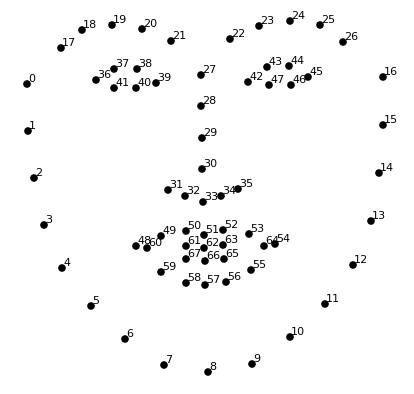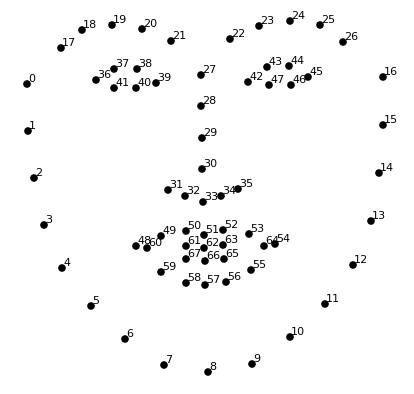

In [3]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리


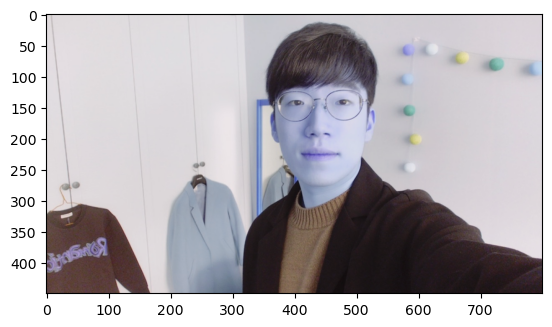

In [4]:
home_dir = os.getenv('HOME')
man_image_path = os.path.join(home_dir, 'work/workplace/Computer_Vision/CV01/images/man_800_600.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(man_image_path, 1)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

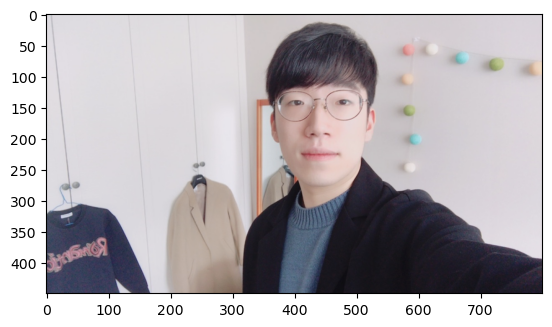

In [5]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

## 2-1 얼굴 검출하기

### dlib에서 얼굴 감지기 불러오기

In [6]:
detector_hog = dlib.get_frontal_face_detector()

### 얼굴 감지기를 사용해서 얼굴 위치 구하기 (rect 값)

In [7]:
rects = detector_hog(img_rgb, 1)


In [8]:
print(rects)

rectangles[[(345, 98) (531, 284)]]


In [9]:
print(len(rects))

1


### 아까 저장해둔 img_show 이미지에 사각형을 그리고 BGR2RGB 컨버팅후 출력

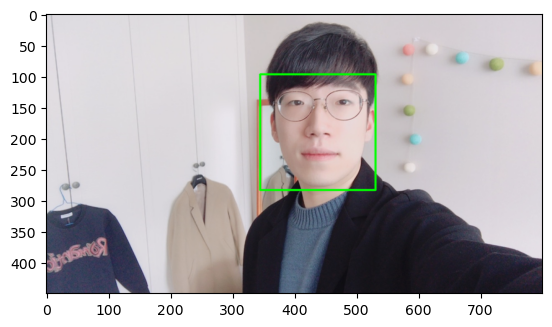

In [10]:
for rect in rects: # 찾은 얼굴 영역의 좌표
    l = rect.left() # 왼쪽
    t = rect.top() # 위쪽
    r = rect.right() # 오른쪽
    b = rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

## 2-2. 랜드마크 검출
얼굴 위치를 박스형태로 찾고 내부에 랜드마크를 찾는 top-down 방식으로 찾아봅니다.

모델은 ibug 300w 데이터셋을 사용해서 68개의 랜드마크가 있다고하는데 제공된 표를 보니 XM2VTS를 말하는거 같습니다. 

모델파일이름은 shape_predictor_68_face_landmarks.dat 입니다

In [11]:
# 1. 모델 경로
model_path = "./models/shape_predictor_68_face_landmarks.dat"

# 2. 모델 로드
landmark_predictor = dlib.shape_predictor(model_path)

# 3. 랜드마크 변수 선언
list_landmarks = []

# 4. 이미 찾은 얼굴영역에서 랜드마크 정보를 추출합니다. 현재는 한 개 이지만 얼굴이 여러개일수도 있어서 for문 사용.
for rect in rects:
    
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_rgb, rect)
    
    # 각 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


### 2-1에서 img_show에 얼굴을 검출하고사각형으로 표시해뒀는데 여기에 랜드마크도 그려줍니다.

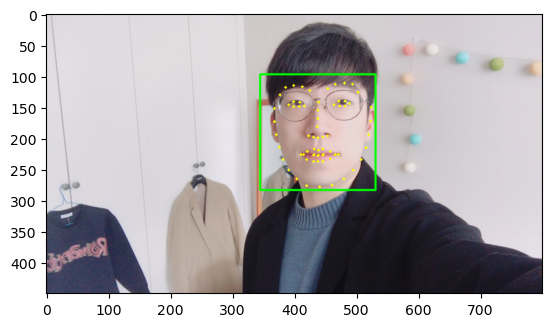

In [12]:
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()
# 이미지를 출력

## Step 3. 스티커 적용 위치 확인하기

예제에서 왕관을 씌웠던걸 생각해보면 x좌표는 스티커가 출력될 중간 좌표였던것같은데 y좌표가는 분명 코에서 h/2만 빼줬거든요 근데 사각형위에 잘 그려졌어요, x좌표는 중간이고 y좌표는 출력될 스티커의 아랫부분 좌표가 필요한걸까요? 잘 모르니까 일단 그려보겠습니다.

또, 고려해야 할 부분이 왕관은 얼굴 검출 사각형 크기와 너비가 같아도 고양이 수염은 한번 생각해볼 필요가 있어요. 실제 고양이는 수염이 얼굴보다 좌우로 돌출되어 있지만, 우리가 사용하는 고양이 수염 이미지는 털 두께가 두껍고 코까지 그려져있어서 너무 크면 또 이상할거같아요. 이것역시 출력부터 해봐야겠네요 일단은 왕관처럼 사각형 너비에맞게 리사이즈하는것으로 해보겠습니다.

## 3-1. 수염위치 계산
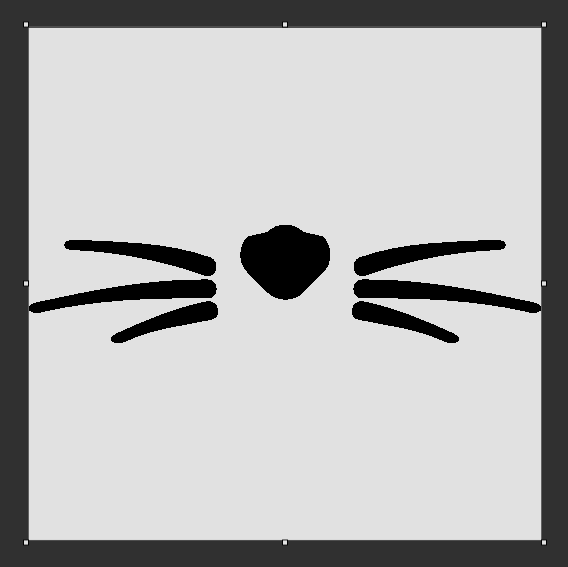
사진 중앙보다 살짝 위에 고양이 코가있어서 인중 위치 33번에 출력하면 코가 오버랩되어 적당히 그려질것 같습니다.

In [13]:
for rect, landmark in zip(rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[33]) # 코의 index는 30 입니다
    x = landmark[33][0] # 이미지에서 코 부위의 x값
    y = landmark[33][1] # 이미지에 코
    w = h = rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(438, 200)
(x,y) : (438,200)
(w,h) : (187,187)


## 3-2. 수염이 출력될 위치가 사진을 벗어나는지 확인하고 예외처리

In [37]:
def read_image_with_alpha(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if img.shape[2] == 4:
        return img  # BGRA 4채널 그대로 리턴
    
    # 알파 없으면 알파채널 추가 (255로 채움 = 완전 불투명)
    alpha = np.full(img.shape[:2], 255, dtype=np.uint8)
    return np.dstack([img, alpha])  # BGR + A → BGRA

In [24]:
def scale_image(image, size, scale=1):
    """
    image : 스케일링할 이미지
    size  : 기준 크기 (w, h) 튜플
    scale : 배율 (기본값 1, float 가능 ex. 0.5, 1.5)
    """
    w, h = size
    new_w = int(w * scale)
    new_h = int(h * scale)
    return cv2.resize(image, (new_w, new_h)), new_w, new_h

### clipping_image 함수
#### 추가할 이미지(스티커)가 원본이미지가 밖으로 벗어나는걸 해결.

7──8──9   anchor= 7 : 스티커 왼쪽위가 좌표에 맞춰짐

4──5──6   anchor= 5 : 스티커 중앙이 좌표에 맞춰짐 (기존 동작)

1──2──3   anchor= 3 : 스티커 오른쪽아래가 좌표에 맞춰짐

### 사용 예시
img_sticker, refined_x, refined_y = clipping_image(

    img_show,       # 원본
    
    img_sticker,    # 스티커
    
    x, y,           # 기준 좌표 (랜드마크 등)
    
    anchor_point=5  # 기본값: 중앙 기준
)

In [26]:
def clipping_image(rect_original, img_sticker, x, y, anchor_point=5):
    """
    rect_original : 원본 이미지 (shape 참조용)
    img_sticker   : 스티커 이미지
    width, height : 스티커 붙일 기준 좌표 (얼굴 랜드마크 등)
    anchor_point  : 숫자패드 기준 앵커 (7=좌상, 8=상, 9=우상,
                                        4=좌, 5=중앙, 6=우,
                                        1=좌하, 2=하, 3=우하)
    return        : clipping된 img_sticker, refined_x, refined_y
    """
    img_h, img_w = rect_original.shape[:2]
    sticker_h, sticker_w = img_sticker.shape[:2]

    # 앵커포인트별 오프셋 계산
    anchor_offset = {
        7: (0,           0          ),
        8: (sticker_w//2, 0         ),
        9: (sticker_w,   0          ),
        4: (0,           sticker_h//2),
        5: (sticker_w//2, sticker_h//2),
        6: (sticker_w,   sticker_h//2),
        1: (0,           sticker_h  ),
        2: (sticker_w//2, sticker_h ),
        3: (sticker_w,   sticker_h  ),
    }

    offset_x, offset_y = anchor_offset[anchor_point]
    refined_x = x - offset_x
    refined_y = y - offset_y

    print(f'(x,y) : ({refined_x},{refined_y})')

    # 왼쪽/위쪽 clipping
    if refined_x < 0:
        img_sticker = img_sticker[:, -refined_x:]
        refined_x = 0
    if refined_y < 0:
        img_sticker = img_sticker[-refined_y:, :]
        refined_y = 0

    # 오른쪽/아래쪽 clipping
    if refined_x + img_sticker.shape[1] > img_w:
        img_sticker = img_sticker[:, :img_w - refined_x]
    if refined_y + img_sticker.shape[0] > img_h:
        img_sticker = img_sticker[:img_h - refined_y, :]

    return img_sticker, refined_x, refined_y

In [31]:
def overlay_image(img_original, img_sticker, refined_x, refined_y, mode='color', color=(0,0,0)):
    result = img_original.copy()
    h, w = img_sticker.shape[:2]
    roi = result[refined_y:refined_y+h, refined_x:refined_x+w]

    if mode == 'alpha':
        if img_sticker.shape[2] != 4:
            raise ValueError("alpha 모드는 IMREAD_UNCHANGED로 읽은 BGRA 이미지가 필요합니다.")
        bgr   = img_sticker[:, :, :3]
        alpha = img_sticker[:, :, 3:] / 255.0
        roi_blended = (roi * (1 - alpha) + bgr * alpha).astype(np.uint8)

    elif mode == 'color':
        mask = np.all(img_sticker == color, axis=2)
        roi_blended = np.where(mask[:, :, np.newaxis], roi, img_sticker).astype(np.uint8)

    result[refined_y:refined_y+h, refined_x:refined_x+w] = roi_blended
    return result

In [57]:
img_sticker = read_image_with_alpha("./images/cat-whiskers.png")
print("read 후:", img_sticker.shape)  # (h, w, 4) 여야 함

img_scaled_sticker, new_w, new_h = scale_image(img_sticker, (w,h), 1)
print("scale 후:", img_clipped_sticker.shape)

print (img_sticker.shape, new_w, new_h)

read 후: (512, 512, 4)
scale 후: (374, 374, 4)
(512, 512, 4) 187 187


## 3-3 수염 그리기

In [58]:
img_clipped_sticker, refined_x, refined_y = clipping_image(img_show, img_scaled_sticker, x, y)
print("clip 후:", img_clipped_sticker.shape)


(x,y) : (345,107)
clip 후: (187, 187, 4)


In [59]:
combined_img = overlay_image(img_show, img_clipped_sticker, refined_x, refined_y, "alpha")

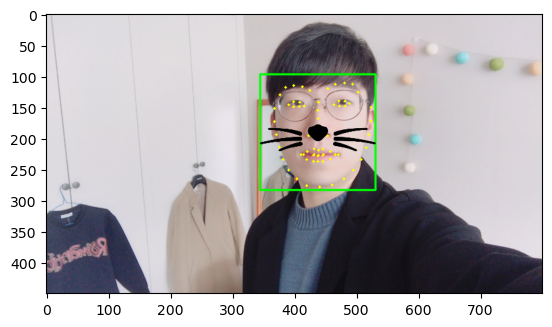

In [60]:
plt.imshow(cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB))
plt.show()

## Step 4. 스티커 적용하기

In [61]:
man_dir = "./images/man_800_600.png"
img_man = cv2.imread(man_dir, 1)    # OpenCV로 이미지를 불러옵니다
img_man_show = img_man.copy()

### 새로 불러온 깨끗한 이미지에서 새로 랜드마크 검출

In [62]:
# 위에서 불러온 모델 재사용.
# 3. 랜드마크 변수 선언
list_landmarks = []

# 4. 이미 찾은 얼굴영역에서 랜드마크 정보를 추출합니다. 현재는 한 개 이지만 얼굴이 여러개일수도 있어서 for문 사용.
for rect in rects:
    
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_man, rect)
    
    # 각 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


### 새로 불러온 깨끗한 이미지에서 새로 Rect (x,y,w,h) 추출

In [ ]:
for rect, landmark in zip(rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[33]) # 코의 index는 30 입니다
    x = landmark[33][0] # 이미지에서 코 부위의 x값
    y = landmark[33][1] # 이미지에 코
    w = h = rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

In [63]:
# 위에서 불러옴
#img_sticker = read_image_with_alpha("./images/cat-whiskers.png")
#print("read 후:", img_sticker.shape)  # (h, w, 4) 여야 함

img_scaled_sticker, new_w, new_h = scale_image(img_sticker, (w,h), 1)
#print("scale 후:", img_clipped_sticker.shape)

img_clipped_sticker, refined_x, refined_y = clipping_image(img_man_show, img_scaled_sticker, x, y)
#print("clip 후:", img_clipped_sticker.shape)

img_man_show = overlay_image(img_man, img_clipped_sticker, refined_x, refined_y, "alpha")

(x,y) : (345,107)


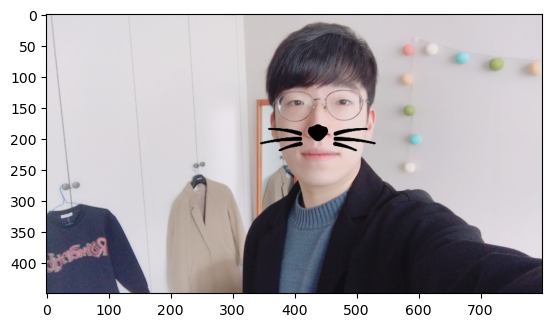

In [64]:
plt.imshow(cv2.cvtColor(img_man_show, cv2.COLOR_BGR2RGB))
plt.show()

## 내 사진으로 해보기

In [76]:
manbo_dir = "./images/test.jpg"
img_manbo = cv2.imread(manbo_dir, 1)    # OpenCV로 이미지를 불러옵니다
img_manbo_show = img_manbo.copy()
print(img_manbo.shape)

(1080, 1920, 3)


In [78]:
rects = detector_hog(img_manbo, 1)

In [79]:
len(rects)

1

In [80]:
# 위에서 불러온 모델 재사용.
# 3. 랜드마크 변수 선언
list_landmarks = []

# 4. 이미 찾은 얼굴영역에서 랜드마크 정보를 추출합니다. 현재는 한 개 이지만 얼굴이 여러개일수도 있어서 for문 사용.
for rect in rects:
    
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_manbo, rect)
    
    # 각 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


In [81]:
for rect, landmark in zip(rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[33]) # 코의 index는 30 입니다
    x = landmark[33][0] # 이미지에서 코 부위의 x값
    y = landmark[33][1] # 이미지에 코
    w = h = rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(1243, 728)
(x,y) : (1243,728)
(w,h) : (556,556)


In [82]:
# 위에서 불러옴
#img_sticker = read_image_with_alpha("./images/cat-whiskers.png")
#print("read 후:", img_sticker.shape)  # (h, w, 4) 여야 함

img_scaled_sticker, new_w, new_h = scale_image(img_sticker, (w,h), 1)
#print("scale 후:", img_clipped_sticker.shape)

img_clipped_sticker, refined_x, refined_y = clipping_image(img_manbo, img_scaled_sticker, x, y)
#print("clip 후:", img_clipped_sticker.shape)

img_manbo_show = overlay_image(img_manbo, img_clipped_sticker, refined_x, refined_y, "alpha")

(x,y) : (965,450)


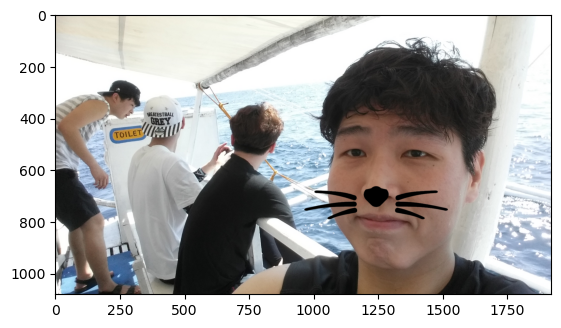

In [83]:
plt.imshow(cv2.cvtColor(img_manbo_show, cv2.COLOR_BGR2RGB))
plt.show()


# Step 5. 문제점 찾아보기

(1) 셀프 카메라를 다양한 각도에서 촬영하면서 스티커를 반복해서 적용해 보세요.
(2) 문제점이 무엇인지 최대한 자세하게 기록해 보세요. 여러분이 생각한 문제점을 해결하기 위한 방법은 분명 존재합니다!

오늘 만든 스티커앱에서 생각해볼 수 있는 문제점은 다음과 같습니다.

얼굴 각도에 따라 스티커가 어떻게 변해야할까요?

#### 예제에있던 정면사진은 고양이 수염이 어울렸으나, 살짝 15도정도 회전된 사진을 사용하니까 바로 어색함이 보입니다.
#### 이런경우 이미지를 기울이거나 하는 변형하는 스킬이 필요하다고 생각됩니다.
#### 또, 이미지 변환도 어느정도 한계가있어서 45도정도 회전된 수염모습 90도정도 회전된 수염모습 
#### 135도정도 회전된 수염모습 (이땐 한쪽만보이겠죠?) 필요해보입니다 180도는 뒷모습이라 안보이는게 당연합니다.

#### 더좋은 방법으로는 2D이미지보다는 3D이미지로 증강현실 느낌으로 실시간 렌더링(3D그래픽 레스터라이즈)된 이미지를 
#### 회전하는것에 맞춰서 그려주는것이 더 좋겠습니다.

멀리서 촬영하면 왜 안될까요? 옆으로 누워서 촬영하면 왜 안될까요?

#### 멀리서 촬영해서 사진에 얼굴이 너무 작게나오거나 누워서 촬영해서 얼굴이 옆으로 누워있으면 검출이 안될수가있습니다.

실행 속도가 중요할까요?
#### 실행속도라는게 이 앱을 만드는속도라면? 공부할때는 아니요, 실무에서는 네 중요합니다.
#### 이미지 프로세싱하는 속도를 말씀하시는거라면? 네 중요합니다. 이게 너무 느리면 움직이는 영상에 적용하기에는 너무 버벅여서 사용자가 품질이 떨어진다고 여기거나
#### 쓸모없는 앱 프로그램이라고 생각할수 있습니다.

스티커앱을 만들 때 정확도가 얼마나 중요할까요?
#### 재미로쓰는 프로그램이라면 다소 덜중요하지만 상업용 프로그램이라면 정확도가 높을수록 좋겠지요.

## 추가 유틸리티 함수

In [86]:
def get_list_landmarks(image, rects):
    list_landmarks = []

    for rect in rects:
        points = landmark_predictor(image, rect)
        list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        list_landmarks.append(list_points)
    
    return list_landmarks

In [85]:
def get_face_landmarks_info(rects, list_landmarks, landmark_index=33):
    """
    rects           : 얼굴 영역 리스트
    list_landmarks  : 랜드마크 리스트
    landmark_index  : 기준 랜드마크 인덱스 (기본값 33=코)
    return          : [(x, y, w, h), (x, y, w, h), ...] 얼굴 수만큼
    """
    results = []
    for rect, landmark in zip(rects, list_landmarks):
        x = landmark[landmark_index][0]
        y = landmark[landmark_index][1]
        w = h = rect.width()
        print(f'landmark[{landmark_index}] : {landmark[landmark_index]}')
        print(f'(x,y) : ({x},{y})')
        print(f'(w,h) : ({w},{h})')
        results.append((x, y, w, h))
    
    return results

In [97]:
def auto_run_framekwork(img_path, detector, sticker_path, anchor_point=5, sticker_scale=1, landmark_index= 33):
    img_rgb = cv2.imread(img_path, 1)    
    img_show = img_rgb.copy()
    print(f"--------------------------------")
    print(f"loaded image shape: {img_rgb.shape}")

    rects = detector(img_rgb, 1)
    list_landmarks = get_list_landmarks(img_rgb, rects)
    
    print(f"length_of_landmarks: = {len(list_landmarks)}")
    list_landmarks_info = get_face_landmarks_info(rects, list_landmarks, landmark_index)

    img_sticker = read_image_with_alpha(sticker_path)
    print("read 후:", img_sticker.shape)  # (h, w, 4) 여야 함
    
    img_scaled_sticker, new_w, new_h = scale_image(img_sticker, (w,h), sticker_scale)
    print("scale 후:", img_scaled_sticker.shape)
    
    img_clipped_sticker, refined_x, refined_y = clipping_image(img_rgb, img_scaled_sticker, x, y, anchor_point)
    print("clip 후:", img_clipped_sticker.shape)
    
    img_show = overlay_image(img_rgb, img_clipped_sticker, refined_x, refined_y, "alpha")

    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

    

--------------------------------
loaded image shape: (768, 1365, 3)
length_of_landmarks: = 0
read 후: (512, 512, 4)
scale 후: (139, 139, 4)
(x,y) : (1243,728)
clip 후: (40, 122, 4)


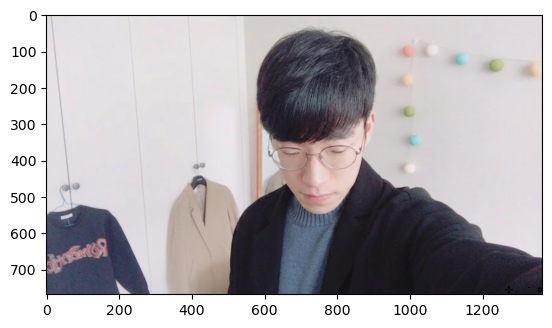

In [98]:
# 위에서 사용함
# detector_hog = dlib.get_frontal_face_detector()
auto_run_framekwork("./images/man_look_down.png", detector_hog, "./images/tatoo.png", 7, 0.25, 48)

### 얼굴 인식 실패

--------------------------------
loaded image shape: (768, 1365, 3)
length_of_landmarks: = 1
landmark[48] : (655, 406)
(x,y) : (655,406)
(w,h) : (322,322)
read 후: (512, 512, 4)
scale 후: (139, 139, 4)
(x,y) : (1243,728)
clip 후: (40, 122, 4)


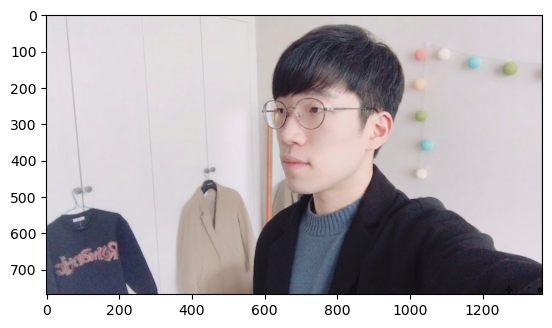

In [100]:
auto_run_framekwork("./images/man_look_left.png", detector_hog, "./images/tatoo.png", 7, 0.25, 48)